# PHYS485/685 — Lab 2 Pre-Lab & Laboratory Notebook

## Student / Lab Information

- **Name:** Darius Gichuru
- **Course:** PHYS485
- **Lab:** Lab 2 — Diode I-V, Lamp I-V, Oscilloscope/Function Generator, RC Time Constant, Wheatstone Bridge
- **Date performed:** 09/09/2026

**Source / integrity note.** This notebook is built from three uploaded sources: the ELMS Lab 2 prelab
assignment, the PHYS485/685 Lab 2 supplement, and the handwritten Lab 2 lecture notes. The physical Hayes
textbook (2N.1–2N.5, 1L.5, 1L.6, 1L.7, 2L.1.1) was **not** provided, so nothing here is presented as a
quotation, page number, or equation "from Hayes." Where the reading is genuinely needed, you'll see:

> [VERIFY AGAINST PHYSICAL HAYES TEXTBOOK]

General theory is standard undergraduate electronics/physics and is labeled as such. **The Lab 2 supplement
overrides the handwritten procedure whenever the two disagree** (mystery boxes → lamp; RC "deduce R, C" →
measure τ only; 1L.7 risetime measurement → output-impedance measurement only). Superseded material is kept
only as background/pre-lab preparation and is explicitly labeled **not performed**.

## ELMS Pre-Lab Requirements Checklist

- [x] **Neat spreadsheet/table setup to fill in results** — "Pre-Built Data Table" in every experiment
- [x] **Circuit diagram for each circuit to be constructed** — "Circuit Diagram Checklist" below + "Circuit Setup" per experiment
- [x] **Graphs and tables pre-set before data taking** — "Pre-Built Data Table" + auto-plot code cells per experiment
- [x] **Verbal/numerical prediction for each measurement** — "Master Prediction Table" below + "Pre-Lab Predictions" per experiment
- [x] **Predicted graph shape** — "Master Prediction Table" below + "Pre-Lab Predictions" per experiment
- [x] **Formula needed for each calculation** — "Relevant Theory" / "RC Theory" / "Bridge Theory" per experiment
- [x] **Answers to questions in the supplement/materials** — "Questions and Pre-Lab Answers" per experiment, plus the two dedicated "All Questions" sections near the end
- [x] **Detailed, well-developed measurement plan** — "Step-by-Step Measurement Plan" per experiment

## Circuit Diagram Checklist

- [ ] **1L.5** — Diode I-V circuit
- [ ] **1L.6** — Lamp I-V circuit
- [x] **1L.7** — Function-generator output-impedance circuit
- [x] **2L.1.1** — RC time-constant circuit
- [x] **Wheatstone bridge**

Component values, instrument placement, and ground location for each circuit are described in that
experiment's "Circuit Setup" section — draw the actual diagram there before lab. No ASCII-art circuit is
used as a substitute.

## Important Limits Before Turning Anything On

**#47 lamp (Experiment 2):**
$$V \le 6.3\ \text{V}, \qquad I \le 0.15\ \text{A}, \qquad P \le 0.945\ \text{W}$$
Stay a bit below all three simultaneously — do not rely on only one limit.

**IN914 diode (Experiment 1):** always use the current-limiting resistor; see the datasheet ratings table below.

**Function generator (Experiment 3):** **NEVER short the output.**

**Oscilloscope / function generator, all sections using both:** the scope ground and function-generator
ground are tied together through the building grounding system, so their ground leads must always land on
the **same** circuit node. Two different ground nodes shorts part of your circuit through the building ground.

**Wheatstone bridge:** supply is the power supply's **fixed 5 V** terminals only; never measure a resistor's
value with the multimeter while it is still connected in an energized circuit.

### IN914 datasheet ratings (ON Semiconductor 1N914/D, Rev. 4 — Absolute Maximum Ratings, $T_A=25^\circ$ C)

| Rating | Symbol | Value |
|---|---|---|
| Average Rectified Forward Current | $I_O$ | 200 mA |
| DC Forward Current | $I_F$ | 300 mA |
| Recurrent Peak Forward Current | $I_f$ | 400 mA |
| Non-repetitive Peak Forward Surge Current (1.0 s pulse) | $I_{FSM}$ | 1.0 A |
| Maximum Repetitive Reverse Voltage | $V_{RRM}$ | 100 V |
| Power Dissipation | $P_D$ | 500 mW |

**IN914 maximum safe current from ELMS datasheet:** the closest match to "maximum current before it burns
up" is the **DC Forward Current $I_F = 300$ mA** rating; $I_O = 200$ mA (average rectified) and $I_f = 400$
mA (recurrent peak) are related but distinct ratings. [VERIFY WHICH SPECIFIC RATING YOUR SPREADSHEET SHOULD
RECORD]. With the 1 kΩ series resistor and a 5 V supply, the worst case current (pot at 0 Ω, diode shorted)
is only $\approx 5$ mA — the resistor keeps you far below any of these limits.

## Master Prediction Table

| Experiment | Quantity / Observation | Prediction | Physical Reason |
|---|---|---|---|
| Diode | Forward I-V | Current stays ~0 until $V_d$ approaches the silicon turn-on region ($\sim$ 0.5–0.7 V), then rises very steeply | Exponential diode law $I = I_s[\exp(V_d/nV_T)-1]$ |
| Diode | Reverse I-V | Current stays extremely small (near instrument noise floor) and roughly flat with increasing reverse voltage | $\exp(V_d/nV_T)-1 \to -1$ for $V_d \ll 0$, so $I \to -I_s$ |
| Diode | Semilog plot | Forward-bias points fall on an approximately straight line before high-injection/series-resistance effects bend it | $\ln I \approx \ln I_s + V_d/(nV_T)$ is linear in $V_d$ |
| Lamp | I-V shape | Concave-down/sub-linear curve: current grows less than proportionally to voltage at higher V | Filament resistance rises with temperature (self-heating) |
| Lamp | Resistance | Cold resistance (low V) much lower than resistance near rated voltage | Tungsten resistivity increases with temperature |
| Lamp | Dynamic resistance vs. I | $R_{dyn} = \Delta V/\Delta I$ increases with current | Higher current → higher filament temperature → higher resistivity |
| Func. gen. | Loaded amplitude vs. $R_{load}$ | $V_{load}$ decreases as $R_{load}$ decreases | Voltage divider between $R_{out}$ and $R_{load}$ |
| Func. gen. | Output impedance | Small, roughly constant $R_{out}$ (likely tens of ohms) extracted from the divider data | Real sources are not ideal; modeled as Thévenin source + $R_{out}$ |
| RC | Predicted $\tau$ | $\tau = RC = (5000\ \Omega)(1\times10^{-9}\ \text{F}) = 5\ \mu\text{s}$ | $\tau=RC$ for a first-order RC circuit |
| RC | 37% level | Discharge reaches $1/e\approx36.8\%$ of its initial value at $t=\tau$ | Exponential decay $V(t)=V_0e^{-t/RC}$ |
| RC | 63% level | Charging reaches $1-1/e\approx63.2\%$ of final value at $t=\tau$ | Exponential rise $V(t)=V_f(1-e^{-t/RC})$ |
| Bridge | Balance | $V_G\to0$ achievable by adjusting $R_2$ since $R_x = R_2 R_3/R_1$ is solvable for some $R_2>0$ | Wheatstone bridge balance condition |
| Bridge | Thermistor warmed | $R_x$ decreases if NTC (typical for a bare-wire thermistor) | Thermistor resistance is strongly temperature-dependent; sign not assumed — see Experiment 5 |

## Background Theory Needed for Lab 2

The ELMS assignment references Hayes 2N.1–2N.5 for this background; that text is not available, so the
topics below are standard undergraduate electronics/physics theory, included only where directly relevant
to an experiment described in the uploaded Lab 2 materials.

> [VERIFY AGAINST PHYSICAL HAYES 2N.1–2N.5 BEFORE LAB]

### Voltage and current measurement; ideal vs. real meters
An ideal voltmeter has infinite input resistance (draws no current); an ideal ammeter has zero resistance
(no voltage drop). Real meters are not ideal: a real DVM has a large but finite input resistance
$R_{in}$ (often ~10 MΩ), and a real ammeter has a small but nonzero "burden" resistance. This imperfection is
the source of every loading-error question in this lab (see the 1L.6 background material and the Wheatstone
bridge notes below).

### Meter loading — two wiring options
When measuring V and I of a device under test (DUT), the ammeter and voltmeter can be arranged two ways:
- **Ammeter close to the source, voltmeter across (ammeter + DUT) together:** the voltmeter reads the
  correct DUT voltage *plus* the ammeter's small voltage drop — voltage reading is biased high.
- **Voltmeter directly across the DUT, ammeter measuring (DUT + voltmeter) current together:** the voltmeter
  reading is exact, but the ammeter also picks up the small current drawn by the voltmeter — current reading
  is biased high.
Neither error can be eliminated at the same time; the better choice depends on how $R_{DUT}$ compares with
the meters' internal resistances (worked through quantitatively in the 1L.6 background section below).

### Source / output impedance (Thévenin model)
Any real source (a lab function generator included) can be modeled as an ideal voltage source $V_{oc}$ in
series with an output resistance $R_{out}$. Loading the source with $R_{load}$ forms a voltage divider:
$$V_{load} = V_{oc}\,\frac{R_{load}}{R_{out}+R_{load}}$$
Measuring $V_{load}$ at several known $R_{load}$ lets you solve for $R_{out}$ — this is exactly Experiment 3.

### Nonlinear circuit elements — the diode
A diode's current-voltage relationship is not linear (not Ohmic). The ideal diode law is
$$I = I_s\left[\exp\!\left(\frac{V_d}{nV_T}\right) - 1\right]$$
where $I_s$ is the (very small) reverse saturation current, $n$ is an ideality factor (device-dependent,
typically 1–2), and $V_T = kT/q \approx 25.85$ mV at room temperature. Neither $I_s$ nor $n$ is assumed known
here — they are properties of the specific IN914 device you measure, not values to look up and use directly.
For $V_d \gg nV_T$ the current grows exponentially (rapid forward conduction); for $V_d \ll 0$ the bracketed
term $\to -1$ and $I \to -I_s$, a very small, nearly voltage-independent reverse current. Because the current
spans many orders of magnitude between reverse bias and forward conduction, a **semilog plot** ($\ln I$ vs.
$V_d$) is far more informative than a linear one — it turns the exponential region into a straight line.

### Resistance vs. dynamic (differential) resistance
For an Ohmic device, $R=V/I$ is constant. For a nonlinear device like the lamp filament, the *static*
resistance $V/I$ still exists at each point, but the *dynamic* (differential) resistance
$$R_{dyn} \approx \frac{\Delta V}{\Delta I}$$
between two nearby measured points better describes the local slope of the I-V curve and is what governs the
device's small-signal behavior at that operating point.

### Oscilloscope measurement principles
Relevant controls: **volts/div** (vertical scale), **time/div** (horizontal scale), **trigger** (stabilizes
a repeating waveform on screen), **DC vs. AC coupling** (DC coupling shows the true absolute waveform,
including any offset — required whenever an absolute voltage level, like the 0%/37%/63% levels in Experiment
4, matters), and **probe attenuation setting** (a 10x probe requires the scope's probe menu to be set to 10x,
or all readings will be off by a factor of 10 — see the supplement's "student torture mode 2" troubleshooting
note).

### RC circuits — exponential charging and discharging
A series RC circuit driven by a step has time constant $\tau = RC$ (units: seconds when R is in ohms and C
in farads). Discharging from $V_0$: $V(t)=V_0 e^{-t/\tau}$; at $t=\tau$, $V/V_0 = e^{-1}\approx 0.368$
(37%). Charging toward $V_f$: $V(t)=V_f(1-e^{-t/\tau})$; at $t=\tau$, $V/V_f = 1-e^{-1}\approx 0.632$ (63%).
Both describe the same underlying time constant, so charging and discharging measured on the same circuit
should agree.

### Wheatstone bridge
A Wheatstone bridge is two resistive voltage dividers fed by the same source, with a voltmeter/galvanometer
connected between the two divider midpoints. At balance, the galvanometer reads zero and the unknown
resistor can be found purely from the ratio of the other three (full derivation in Experiment 5).

# Experiment 1 — 1L.5 Diode I-V Characteristic

## Objective
Measure the current-voltage characteristic of an IN914 diode in both forward and reverse bias, and plot it
on both linear and semilog axes.

## Relevant Theory
See "Nonlinear circuit elements — the diode" above for the diode equation and the reason for the semilog
plot. Reversing the diode's physical orientation in the circuit reverses which direction is "forward."

## Pre-Lab Predictions
- **Forward bias:** current stays near zero for small $V_d$, then rises steeply once $V_d$ approaches the
  silicon turn-on region (typically observed somewhere around a few tenths of a volt to ~0.7 V — exact value
  is a measured property of this device, not assumed in advance).
- **Reverse bias:** current stays very small and roughly flat (near the meter's resolution) as reverse
  voltage increases.
- **Shape:** strongly asymmetric, non-Ohmic curve; a straight line on a semilog (forward-current) plot over
  the exponential region.
- **What happens as forward voltage approaches the normal conduction region:** current increases very
  rapidly (many orders of magnitude for a small increase in $V_d$), which is why the series resistor is
  required to keep the current bounded.

## Circuit Setup

<p align="left">
  <img src="expo1_c1.png" alt="Circuit 1 Diagram" width="340" height="308"><br>
  <b>Circuit 1</b>
</p>

Per the handwritten Lab 2 notes ("Circuit 1: The diode"), build:

- **+5 V supply** → **fixed 1 kΩ resistor** → **100 kΩ potentiometer** (used as a 2-terminal variable
  resistor $R$; per the supplement, wire only two of its three terminals — the slider plus one end — leaving
  the third ("dummy") terminal unconnected) → **ammeter in series** → node.
- At that node, the **IN914 diode** and the **voltmeter** are connected **in parallel**, from the node down
  to **GND**.
- **Ammeter placement:** in series, upstream of the diode/voltmeter parallel pair — it measures the diode
  current plus the small current drawn by the voltmeter (voltmeter input resistance is large, so this is a
  small error; see "Meter loading" above).
- **Voltmeter placement:** directly across the diode, so it reads the true diode voltage.
- **Diode polarity:** note the physical package's cathode band (black band on DO-35 axial package /
  black band on SOD-80) — this determines which physical direction is "forward" in your circuit. To reverse
  bias, physically flip the diode's orientation in the circuit.
- Start with the pot adjusted so the resistance between the two terminals you're using is **zero** — this
  sets the maximum available current for that configuration.

### Measurement / Error Considerations
- The 1 kΩ fixed resistor limits worst-case current to a safe value regardless of pot setting (see limits
  table above).
- Ammeter reads (diode current + voltmeter current); voltmeter's large $R_{in}$ keeps this error small.
- Pot's actual resistance range should be verified with an ohmmeter before trusting nominal 100 kΩ label.

## Step-by-Step Measurement Plan
1. Verify the 100 kΩ pot with an ohmmeter before wiring it in.
2. Build the circuit; set pot resistance to 0 Ω.
3. Set up the diode data-table/plot cells below **before** taking any data.
4. Take a small number of forward-bias points first at the extremes (near 0 Ω and near max pot resistance)
   plus a few in between — **not** equally spaced. Enter each point and re-run the plot cell after every 1–2
   points.
5. Watch the live-updating semilog plot; add more points where the curve is changing rapidly (the knee
   region) and fewer where it's flat.
6. Once forward bias is characterized (a handful of points, e.g. ~5, is enough to see the shape), physically
   reverse the diode and repeat for reverse bias with a few points.
7. Record the pot's *effective usable diode-voltage range* for this circuit (see prediction table and
   Question below) — note it directly from your data.

## Pre-Built Data Table
Data entry and table are produced together with the plots below — see the code cells.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# ---- Experiment 1: Diode data entry ----
# Enter measured points in the order you take them; no need to sort.
V_diode = np.array([
    0.681, 0.601, 0.571, 0.563, 0.539, 0.527, 0.520, 0.501, 0.492, 0.461, 0.615, 0.653
])

I_diode = 10**(-3)* np.array([
    4.35, 0.88, 0.46, 0.39, 0.24, 0.19, 0.16, 0.12, 0.10, 0.05, 1.15, 2.5
])

,V_diode (V),I_diode (A)
0,0.681,0.00435
1,0.601,0.00088
2,0.571,0.00046
3,0.563,0.00039
4,0.539,0.00024
5,0.527,0.00019
6,0.520,0.00016
7,0.501,0.00012
8,0.492,0.00010
9,0.461,0.00005


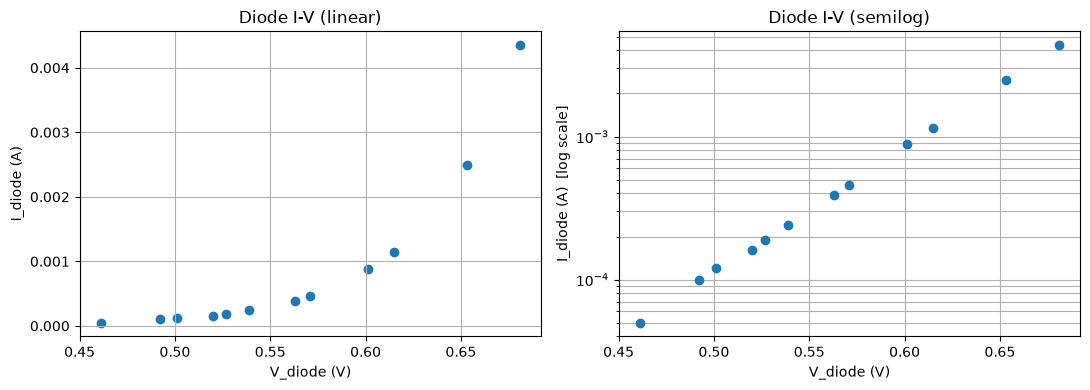

In [21]:
# ---- Experiment 1: Diode table, linear plot, semilog plot ----
if len(V_diode) == 0 or len(I_diode) == 0:
    print("No diode measurements entered yet.")
elif len(V_diode) != len(I_diode):
    print(f"Array length mismatch: V_diode has {len(V_diode)} points, "
          f"I_diode has {len(I_diode)} points. Fix before plotting.")
else:
    df_diode = pd.DataFrame({"V_diode (V)": V_diode, "I_diode (A)": I_diode})
    display(df_diode)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].scatter(V_diode, I_diode, marker="o")
    axes[0].set_xlabel("V_diode (V)")
    axes[0].set_ylabel("I_diode (A)")
    axes[0].set_title("Diode I-V (linear)")
    axes[0].grid(True)

    mask = I_diode > 0  # semilog needs strictly positive current
    if np.any(mask):
        axes[1].semilogy(V_diode[mask], I_diode[mask], "o")
    else:
        axes[1].text(0.5, 0.5, "No positive-current points yet",
                      ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_xlabel("V_diode (V)")
    axes[1].set_ylabel("I_diode (A)  [log scale]")
    axes[1].set_title("Diode I-V (semilog)")
    axes[1].grid(True, which="both")

    plt.tight_layout()
    plt.show()

## Analysis
The linear plot should show the classic diode "knee." The semilog plot's forward-bias points should fall
close to a straight line over the exponential region (before any high-current rollover from the series
resistance) — that's the visual check that the device is behaving like a diode rather than an Ohmic resistor.

## Linear I-V Plot
See code cell above (auto-generated from `V_diode`, `I_diode`).

## Semilog I-V Plot
See code cell above (auto-generated from `V_diode`, `I_diode`).

## Questions and Pre-Lab Answers

**What is the pot's usable diode-voltage range, as found experimentally? Why do you think the circuit was
designed to have this limited range?**
[ENTER MEASURED RANGE FROM YOUR DATA]. The range is limited because the diode's forward voltage is pinned
close to its turn-on value over a huge range of currents (that's the whole point of the exponential I-V
law) — once forward biased, the diode voltage itself barely changes even as the pot varies the current by
orders of magnitude. So the *diode voltage* range you can explore is narrow, even though the *current* range
is huge; that's exactly why the semilog current plot is more useful than trying to sweep voltage finely.

**How would you summarize the voltage vs. current behavior of a diode?**
Strongly nonlinear and asymmetric: essentially no current flows in reverse bias (a tiny, roughly
voltage-independent leakage current), while in forward bias the current rises exponentially once the
voltage approaches the device's turn-on region, per $I = I_s[\exp(V_d/nV_T)-1]$.

**What would happen if you were to put 5 V directly across the diode without adequate current limiting?**
The exponential law means the current would be enormous (theoretically far beyond any of the datasheet
ratings) for even a modest overshoot past the normal forward-conduction voltage — the diode would draw far
more than its maximum rated current (200–400 mA range, see limits table) and would likely be destroyed by
excessive power dissipation. This is exactly why the 1 kΩ series resistor is mandatory.

**Why is the diode-voltage range intentionally limited (via the pot/series resistor)?**
To keep the operating point inside the diode's safe current rating no matter how the pot is adjusted — see
the ≈5 mA worst-case current calculation in the limits section above.

**Why is a current-limiting resistor required?**
Because the diode's dynamic resistance in forward conduction is very low; without a series resistor to set
an operating current, a small increase in applied voltage would produce a runaway increase in current
(thermal runaway / device destruction).

## Experimental Notes / Sources of Error
- Ammeter reads diode current + voltmeter current (small, since voltmeter $R_{in}$ is large).
- Pot contact resistance / wiper noise at very low resistance settings.
- Reverse-bias current may be near or below your ammeter's resolution — note the smallest current you can
  reliably distinguish from zero.
- [ENTER ADDITIONAL NOTES DURING LAB]

# Experiment 2 — 1L.6 Lamp I-V Characteristic

**Supplement override, read first:** the original "mystery box" procedure is **not performed**. Per the
supplement: *"We don't have 'mystery boxes'. Here just make the I-V curve for the lamp... Don't do 1L.6.1...
Ignore the instructions that say measure in 0.1 V increments."* The actual experiment is the I-V
characteristic of the **#47 incandescent lamp**, using whatever spacing the live-updating graph tells you
that you need.

## Objective
Measure the I-V curve of a #47 lamp and its dynamic resistance vs. current, and determine whether it obeys
Ohm's law.

## Relevant Theory
See "Resistance vs. dynamic (differential) resistance" above. A lamp filament heats as current increases,
raising its resistivity — so its I-V curve is expected to be non-Ohmic (sub-linear).

## Pre-Lab Predictions
- Non-linear, concave I-V curve: current rises less than proportionally to voltage as voltage increases.
- Filament heats with increasing current → resistance increases with current.
- Dynamic resistance $R_{dyn}=\Delta V/\Delta I$ should **increase** with current (steeper local slope on a
  V-vs-I plot at higher current).
- Expect the lamp to **not** satisfy Ohm's law (resistance is not constant).

## Circuit Setup

<p align="left">
  <img src="expo2_c1.png" alt="Circuit 2 Diagram" width="340" height="308"><br>
  <b>Circuit 2</b>
</p>

- **Power supply** connected directly across the lamp ("right across the lab," per the supplement) — no
  additional series limiting resistor is specified.
- **Ammeter in series** with the lamp.
- **Voltmeter across the lamp** (not across the power supply's front-panel terminals — see Question below).
- Lamp seats in its socket by pushing down on the pin.

**Component values:** #47 lamp maximum ratings, from the supplement: $V\le6.3$ V, $I\le0.15$ A,
$P\le0.945$ W (all three shown as a warning box below — do not exceed any of them).

> **⚠ #47 LAMP LIMITS: $V \le 6.3$ V, $I \le 0.15$ A, $P \le 0.945$ W — stay a bit below all three.**

### Measurement / Error Considerations
- Front-panel supply voltage is not the same as the voltage actually across the lamp (see Question below) —
  always read the dedicated voltmeter across the lamp itself.
- Filament resistance is temperature-dependent — let readings settle briefly at each setting.
- Approaching the rated limits: take a few points close to (but under) the maxima since that's often where
  behavior changes most.

## Step-by-Step Measurement Plan
1. Set up the pre-built table/plot cells below before taking data.
2. Take a few points at low voltage first to establish the low-current trend.
3. Increase voltage, watching the live I-V plot, adding points where the curve visibly bends; stay under all
   three lamp limits at every step.
4. From the same (V, I) data, the dynamic-resistance cell automatically computes $R_{dyn}$ between
   consecutive points and plots it vs. current.

## Pre-Built Data Table
See code cells below.

In [26]:
# ---- Experiment 2: Lamp data entry ----
V_lamp = np.array([
    0.021, 0.035, 0.072, 0.110, 0.313, 0.534,
    1.034, 1.333, 2.147, 2.550, 1.848
])

I_lamp = 10**(-3)*np.array([
    7.25, 11.75, 20.64, 32.45, 52.62, 66.7,
    91.4, 104.9, 136.6, 150.4, 125.3
])

,V_lamp (V),I_lamp (A),P_lamp (W)
0,0.021,0.00725,0.000152
1,0.035,0.01175,0.000411
2,0.072,0.02064,0.001486
3,0.110,0.03245,0.003570
4,0.313,0.05262,0.016470
5,0.534,0.06670,0.035618
6,1.034,0.09140,0.094508
7,1.333,0.10490,0.139832
8,2.147,0.13660,0.293280
9,2.550,0.15040,0.383520


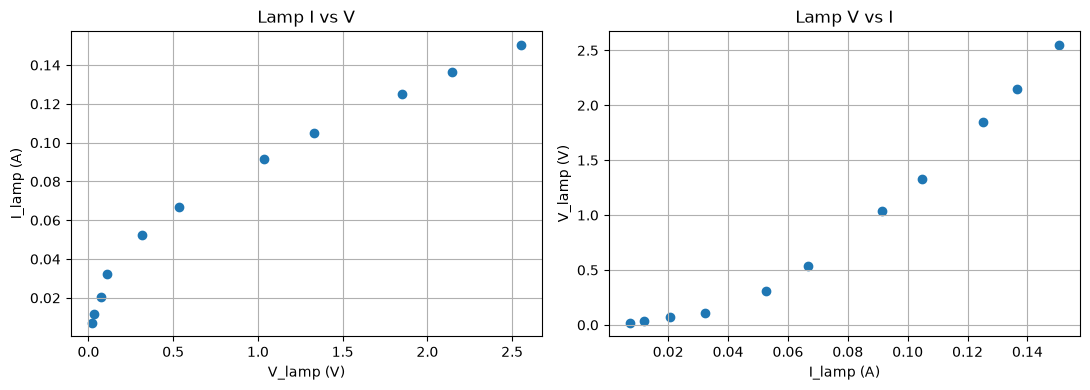

In [27]:
# ---- Experiment 2: Lamp table, I-V plots, dynamic resistance ----
if len(V_lamp) == 0 or len(I_lamp) == 0:
    print("No lamp measurements entered yet.")
elif len(V_lamp) != len(I_lamp):
    print(f"Array length mismatch: V_lamp has {len(V_lamp)} points, "
          f"I_lamp has {len(I_lamp)} points. Fix before plotting.")
else:
    P_lamp = V_lamp * I_lamp
    df_lamp = pd.DataFrame({
        "V_lamp (V)": V_lamp,
        "I_lamp (A)": I_lamp,
        "P_lamp (W)": P_lamp,
    })
    display(df_lamp)

    over_V = np.any(V_lamp > 6.3)
    over_I = np.any(I_lamp > 0.15)
    over_P = np.any(P_lamp > 0.945)
    if over_V or over_I or over_P:
        print("WARNING: one or more entered points exceed the #47 lamp's rated limits!")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(V_lamp, I_lamp, marker ="o")
    axes[0].set_xlabel("V_lamp (V)")
    axes[0].set_ylabel("I_lamp (A)")
    axes[0].set_title("Lamp I vs V")
    axes[0].grid(True)

    axes[1].scatter(I_lamp, V_lamp, marker = "o")
    axes[1].set_xlabel("I_lamp (A)")
    axes[1].set_ylabel("V_lamp (V)")
    axes[1].set_title("Lamp V vs I")
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

,I_mid (A),R_dynamic (ohm)
0,0.009500,3.111111
1,0.016195,4.161980
2,0.026545,3.217612
3,0.042535,10.064452
4,0.059660,15.696023
5,0.079050,20.242915
6,0.098150,22.148148
7,0.115100,25.245098
8,0.130950,26.460177
9,0.143500,29.202899


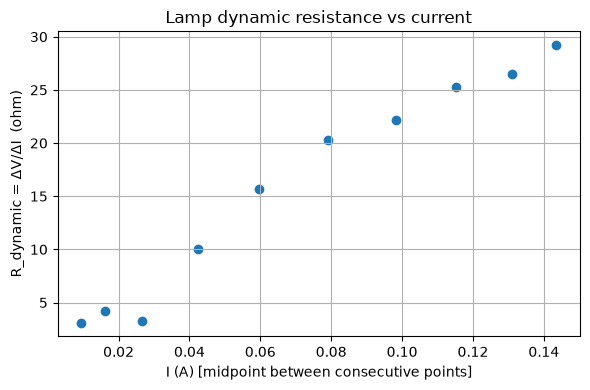

In [29]:
# ---- Experiment 2: Dynamic resistance vs current ----
if len(V_lamp) < 2 or len(I_lamp) < 2:
    print("Need at least two lamp measurements to compute dynamic resistance.")
elif len(V_lamp) != len(I_lamp):
    print("Array length mismatch between V_lamp and I_lamp.")
else:
    order = np.argsort(I_lamp)
    V_sorted = V_lamp[order]
    I_sorted = I_lamp[order]

    dV = np.diff(V_sorted)
    dI = np.diff(I_sorted)
    I_mid = (I_sorted[:-1] + I_sorted[1:]) / 2.0

    with np.errstate(divide="ignore", invalid="ignore"):
        R_dynamic = np.where(dI != 0, dV / dI, np.nan)

    df_dyn = pd.DataFrame({
        "I_mid (A)": I_mid,
        "R_dynamic (ohm)": R_dynamic,
    })
    display(df_dyn)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(I_mid, R_dynamic, marker = "o")
    ax.set_xlabel("I (A) [midpoint between consecutive points]")
    ax.set_ylabel("R_dynamic = ΔV/ΔI  (ohm)")
    ax.set_title("Lamp dynamic resistance vs current")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## I-V Analysis
Sorted by increasing current, points should trace a concave curve (V vs I bends upward as filament heats).

## Dynamic Resistance Analysis
$R_{dyn}$ vs. $I$ should trend upward if the filament is heating with current, consistent with tungsten's
positive temperature coefficient of resistivity.

## Questions and Pre-Lab Answers

**What will happen if you turn the lamp voltage/current/power too high?**
The filament will exceed its rated dissipation and can fail (burn out) — stay a bit below all three #47
ratings ($V\le6.3$ V, $I\le0.15$ A, $P\le0.945$ W) at every measured point.

**Should you use the voltage on the front face of the power supply for your measured value? Why not?**
No — the front-panel reading includes the voltage drop across the leads, contacts, and the ammeter in
series with the lamp, so it is not the voltage actually across the lamp. Use the dedicated voltmeter
connected directly across the lamp itself.

**How should dynamic resistance depend on current?**
It should increase with current, since the filament's temperature (and hence resistivity) rises with
current/power dissipation.

**Does this device satisfy Ohm's law? Why or why not?**
No — Ohm's law requires $V/I$ (and equivalently $dV/dI$) to be constant/independent of current. The lamp's
dynamic resistance changes with current (see plot), so $R$ is not constant and the device is non-Ohmic.

## Experimental Notes / Sources of Error
- Filament thermal time constant — allow the reading to stabilize before recording.
- Front-panel-vs-lamp voltage distinction (see Question above) — always read the lamp-voltmeter, not the
  supply dial.
- [ENTER ADDITIONAL NOTES DURING LAB]

# Experiment 3 — 1L.7 Oscilloscope & Function Generator

**Supplement override, read first:** the equipment here is different from what Hayes assumes — the lab uses
a **Keysight DSOX1103G**, a combined oscilloscope/function generator. Per the supplement, the only
measurement performed in this section is the **function-generator output impedance**; *"Do not do any of the
other measurements discussed in this section."* The handwritten notes' square-wave risetime measurement
(10%-to-90% rise time) is retained below only as **background/pre-lab preparation — not performed** under
the modified procedure, since the supplement scopes this section down to output impedance only.

## Objective
Get comfortable with the DSOX1103G's controls, then measure the function generator's output impedance
$R_{out}$ using a Thévenin-source model.

## Oscilloscope / Function Generator Preparation
Initial practice signal (per supplement): **sine wave, amplitude 0.6 V, frequency 1500 Hz**, output via a
BNC cable, displayed on the scope. Use this to get familiar with:
- volts/div (vertical scale)
- time/div (horizontal scale)
- trigger (level/source, to stabilize the displayed waveform)
- waveform shape selection
- frequency and amplitude controls

**Background/pre-lab question — not performed in the modified Lab 2 procedure:** the handwritten notes also
describe switching to a square wave and measuring its 10%-to-90% risetime. See "Questions from Handwritten
Lab Notes" near the end of this notebook for the conceptual answer; this measurement itself is not part of
the modified Experiment 3.

## Common-Ground Warning

> ** DO NOT CONNECT OSCILLOSCOPE / FUNCTION-GENERATOR GROUNDS TO TWO DIFFERENT CIRCUIT NODES. **
>
> The scope's ground and the function generator's ground are electrically common through the building's
> equipment grounding system — they are effectively hard-wired together regardless of where you clip them.
> If you connect them to two different circuit nodes, you unintentionally short those two nodes together
> through the building ground, which can short out part of your circuit, produce wrong readings, or damage
> components. Always route both ground connections to the **same** circuit node.

**Troubleshooting note (from the supplement):** if the oscilloscope voltage reads roughly **10× too large**,
check/reset the channel's probe attenuation setting (press the channel softkey for the probe menu, select
"Probe," reset to the correct attenuation).

## Function Generator Output Impedance
Model the function generator as an ideal source $V_{oc}$ in series with output resistance $R_{out}$, driving
an external load $R_{load}$:
$$V_{load} = V_{oc}\,\frac{R_{load}}{R_{out}+R_{load}}$$
Solving for the output resistance:
$$R_{out} = R_{load}\left(\frac{V_{oc}}{V_{load}} - 1\right)$$
**Assumptions:** the source's open-circuit amplitude $V_{oc}$ doesn't change with frequency/loading over the
range used; the scope's own input impedance is high enough not to load the circuit; the frequency is low
enough that reactive effects in cabling/probes are negligible (see Question below).

## Circuit Setup

<p align="left">
  <img src="expo3_c1.png" alt="Circuit 3 Diagram" width="340" height="308"><br>
  <b>Circuit 3</b>
</p>

- **Function generator output** → **$R_{load}$** (resistance box) → back to function generator ground/common.
- **Oscilloscope probe** connected across $R_{load}$ to read $V_{load}$.
- **Common ground:** function-generator ground and oscilloscope ground must land at the same node (the low
  side of $R_{load}$) — see warning above.
- First measurement: open-circuit (no load / $R_{load}\to\infty$, or simply disconnected) amplitude, $V_{oc}$.
- Then step $R_{load}$ through a range of values and record the resulting $V_{load}$ at each.

### Measurement / Error Considerations
- Use a relatively low frequency (see Question below) to avoid cable/probe reactance corrupting $R_{out}$.
- Probe attenuation setting must match reality (10x troubleshooting note above).
- Contact/lead resistance in the resistance box can bias small $R_{load}$ readings.

## Step-by-Step Measurement Plan
1. Set the function generator to a sine wave at a fixed, relatively low frequency (well below the practice
   1500 Hz signal is a reasonable starting point — see Question on why low frequency is preferred).
2. Measure $V_{oc}$ with $R_{load}$ removed (open circuit).
3. Step through several $R_{load}$ values (including some comparable in magnitude to your rough guess for
   $R_{out}$, since that's where the divider is most sensitive) and record $V_{load}$ at each, watching the
   live plot below.
4. Compute $R_{out}$ from each pair and compare to the mean/fit result.

## Pre-Built Data Table
See code cells below.

In [56]:
# ---- Experiment 3: Function generator output-impedance data entry ----
V_open_circuit = 6.4 # volts

R_load = np.array([
900*10**3+90, 90*10**3+90, 9*10**3+90, 900+90, 90, 9
])

V_load = np.array([
5.9, 5.8, 5.575, 5.675, 3.85, 975*10**(-3)
]) 

,R_load (ohm),V_load (V),R_out estimate (ohm)
0,900090,5.900,76278.813559
1,90090,5.800,9319.655172
2,9090,5.575,1345.156951
3,990,5.675,126.475771
4,90,3.850,59.610390
5,9,0.975,50.076923


Mean R_out estimate: 1.45e+04 ohm
Std dev of R_out estimates: 3.05e+04 ohm


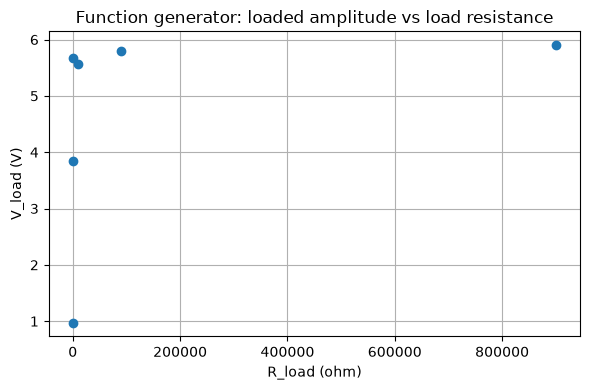

In [57]:
# ---- Experiment 3: Rout calculation and plot ----
if np.isnan(V_open_circuit):
    print("Enter V_open_circuit before computing R_out.")
elif len(R_load) == 0 or len(V_load) == 0:
    print("No loaded measurements entered yet.")
elif len(R_load) != len(V_load):
    print(f"Array length mismatch: R_load has {len(R_load)} points, "
          f"V_load has {len(V_load)} points. Fix before plotting.")
else:
    with np.errstate(divide="ignore", invalid="ignore"):
        R_out_estimates = R_load * (V_open_circuit / V_load - 1.0)

    df_fg = pd.DataFrame({
        "R_load (ohm)": R_load,
        "V_load (V)": V_load,
        "R_out estimate (ohm)": R_out_estimates,
    })
    display(df_fg)

    valid = np.isfinite(R_out_estimates)
    if np.any(valid):
        print(f"Mean R_out estimate: {np.mean(R_out_estimates[valid]):.3g} ohm")
        print(f"Std dev of R_out estimates: {np.std(R_out_estimates[valid], ddof=1) if valid.sum() > 1 else float('nan'):.3g} ohm")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(R_load, V_load, "o", label="measured")
    ax.set_xlabel("R_load (ohm)")
    ax.set_ylabel("V_load (V)")
    ax.set_title("Function generator: loaded amplitude vs load resistance")
    ax.grid(True)

    # Optional simple fit of Vload(Rload) = Voc * Rload / (Rout + Rload)
    # if np.any(valid) and valid.sum() >= 2:
    #     try:
    #         from scipy.optimize import curve_fit

    #         def divider_model(Rl, Rout):
    #             return V_open_circuit * (Rl / (Rout + Rl))

    #         popt, _ = curve_fit(divider_model, R_load, V_load, p0=[np.mean(R_out_estimates[valid])])
    #         Rout_fit = popt[0]
    #         print(f"Fitted R_out (voltage-divider model): {Rout_fit:.3g} ohm")

    #         R_fit_axis = np.linspace(min(R_load.min(), 1), R_load.max() * 1.1, 200)
    #         ax.plot(R_fit_axis, divider_model(R_fit_axis, Rout_fit), "-", label="fit")
    #         ax.legend()
    #     except Exception as e:
    #         print("Fit skipped:", e)

    plt.tight_layout()
    plt.show()

## Output-Impedance Analysis
Individual $R_{out}$ estimates (one per loaded point), their mean, and standard deviation are printed above;
the optional curve fit overlays the voltage-divider model on the data.

## Questions and Pre-Lab Answers

**Why should a relatively low-frequency signal be used for the output-impedance measurement?**
At higher frequencies, cable capacitance, probe input capacitance, and any reactive component of the
source's own output impedance become significant, so the simple resistive divider model
$V_{load}=V_{oc}R_{load}/(R_{out}+R_{load})$ stops accurately describing the circuit. A low frequency keeps
all of these reactive effects negligible so the extracted $R_{out}$ reflects the purely resistive output
impedance.

**How can $R_{out}$ be extracted from the data?**
By loading the source with a series of known $R_{load}$ values, measuring the resulting $V_{load}$ at each,
and either solving $R_{out}=R_{load}(V_{oc}/V_{load}-1)$ point-by-point or fitting the full data set to the
voltage-divider model (both done automatically in the code cell above).

**Why should you NEVER short the function-generator output?**
Shorting the output ($R_{load}=0$) forces the entire open-circuit voltage across only $R_{out}$, driving the
maximum possible current from the source — this can exceed the generator's internal current limits and
damage the output stage.

**What does SYNC OUT / TTL mean conceptually?**
SYNC OUT / TTL provides a separate digital timing/logic-level output (TTL = transistor-transistor logic,
i.e. a signal that switches between standard logic-level voltages) synchronized to the main analog waveform
— useful for triggering other equipment in sync with the generated waveform, independent of the analog
output's amplitude/shape.

**What does the oscilloscope CAL output provide conceptually?**
A known, fixed reference signal (typically a square wave of stated amplitude/frequency) that the scope
provides at a dedicated terminal, intended for verifying/calibrating probe compensation and confirming the
scope's vertical and horizontal scales are reading correctly.

[VERIFY EXACT OUTPUT LEVEL ON EQUIPMENT / MANUAL] — the specific CAL amplitude/frequency and the exact
SYNC OUT/TTL levels for the DSOX1103G are not stated in the uploaded materials.

## Experimental Notes / Sources of Error
- Probe attenuation setting (10x troubleshooting note above) — verify before trusting any reading.
- Common-ground violation would corrupt every reading in this section — double-check wiring.
- Resistance-box tolerance/contact resistance at low $R_{load}$.
- [ENTER ADDITIONAL NOTES DURING LAB]

# Experiment 4 — 2L.1.1 RC Time Constant

**Supplement override, read first:** *"Measure the time constant only. Do not do the other parts... Do not
do the part where it says 'deduce the r and c' or beyond."* Use fixed discrete components: **R = 5000 Ω,
C = 1 nF** (supplement: *"We will not provide wrapped components... Best to use discrete components... not
the resistor/capacitor box. They are too low quality."*). The handwritten notes' later procedure for
*experimentally deducing* R and C via a voltage divider / phase-shift method is retained only as
**background/pre-lab preparation — not performed** under the modified procedure.

## Objective
Measure the RC time constant $\tau$ of a known R, C pair from a square-wave charge/discharge and compare to
the predicted value.

## RC Theory
For a series RC circuit driven by an ideal step:
$$\tau = RC$$
**Discharge** from initial value $V_0$: $V(t) = V_0 e^{-t/\tau}$. At $t=\tau$: $V/V_0 = e^{-1}\approx 0.368$
(37%).
**Charging** toward final value $V_f$: $V(t) = V_f\left(1-e^{-t/\tau}\right)$. At $t=\tau$: $V/V_f =
1-e^{-1}\approx 0.632$ (63%). Both describe the *same* underlying $\tau$, so a charging measurement and a
discharging measurement on the same circuit should agree — if they don't, something in the setup is off
(see the Step-by-Step plan below).

## Numerical Prediction

In [59]:
# ---- Experiment 4: theoretical tau ----
R_nominal = 5000       # ohm
C_nominal = 1e-9       # F
R_true = 5.065*10**3    # ohms
C_true = 0.828*10**(-9)
V_in = 1.00 # volts pkpk

tau_predicted = R_nominal * C_nominal
print(f"R = {R_nominal} ohm, C = {C_nominal*1e9:.3g} nF")
print(f"Predicted tau = R*C = {tau_predicted:.3e} s = {tau_predicted*1e6:.3g} microseconds")

R = 5000 ohm, C = 1 nF
Predicted tau = R*C = 5.000e-06 s = 5 microseconds


## Circuit Setup

<p align="left">
  <img src="expo4_c1.png" alt="Circuit 4 Diagram" width="340" height="308"><br>
  <b>Circuit 4</b>
</p>
<p align="left">
  <img src="expo4_c2.png" alt="Circuit 5 Diagram" width="340" height="308"><br>
  <b>Circuit 5</b>
</p>

- **Function generator** (square wave) → **5000 Ω discrete resistor** in series with **1 nF discrete
  capacitor** → back to function-generator ground.
- **Oscilloscope probe** across the capacitor (to observe the exponential charge/discharge).
- **Common ground:** function-generator ground and scope ground at the same node — see the common-ground
  warning in Experiment 3; it applies here too.
- **Square wave must transition 0 V → positive voltage** (not negative-to-positive), per the supplement.

### Measurement / Error Considerations
- Probe attenuation setting (same 10x issue as Experiment 3).
- Square-wave period must be long enough, relative to $\tau$, for the capacitor to fully charge and
  discharge each half-cycle (see Question below) — otherwise the waveform never reaches its asymptotic
  levels and the 37%/63% method is invalid.
- Component tolerances on the discrete R, C (not given in the uploaded materials) —
  [ENTER SPEC IF REQUIRED].

## Scope Setup
- Square wave, transitioning 0 V → positive.
- **DC coupling** on the input (required — AC coupling would remove the absolute 0%/100% reference levels).
- Time/div set so the fall from 100% to ~37% (or rise from 0% to ~63%) fills most of the screen.
- Use cursors, and/or the percent markings on the scope screen, to identify the 100%, 63%, 37%, and 0%
  levels.

## Signal Setup
Drive with a square wave at roughly 500 Hz or below (per the handwritten notes), adjusting frequency as
needed to get a clean, well-resolved image. The period must be long compared with $\tau$ so the capacitor
has time to meaningfully charge and discharge each half-cycle — do not assume one exact required frequency;
tune it experimentally.

## Step-by-Step Measurement Plan
1. Wire the circuit; set the function generator to a square wave, 0 V → positive, at an initial frequency
   ≤ 500 Hz.
2. Set the scope to DC coupling; use Auto-scale, then fine-tune time/div so most of the screen shows the
   fall from 100% to ~37% (or the rise from 0% to ~63%).
3. Using cursors, measure the time for the output to fall to 37% of its initial value → this is
   $\tau_{discharge}$.
4. Measure the time to rise from 0% to 63% of the final value → this is $\tau_{charge}$.
5. Compare the two — they should agree; if not, adjust the square-wave frequency and re-measure (see
   RC Theory above for why).
6. Enter both measured values in the data cell below and compare with the predicted $\tau$.

## Pre-Built Data Table
See code cells below.

In [ ]:
# ---- Experiment 4: measured tau data entry ----
tau_discharge_measured = np.nan   # seconds
tau_charge_measured = np.nan      # seconds

In [ ]:
# ---- Experiment 4: comparison to prediction ----
rows = []
for label, tau_meas in [("Discharge (37%)", tau_discharge_measured),
                          ("Charge (63%)", tau_charge_measured)]:
    if np.isnan(tau_meas):
        pct_diff = np.nan
    else:
        pct_diff = 100.0 * (tau_meas - tau_predicted) / tau_predicted
    rows.append({"Method": label, "tau_measured (s)": tau_meas,
                 "tau_predicted (s)": tau_predicted, "% difference": pct_diff})

df_tau = pd.DataFrame(rows)
display(df_tau)

if not (np.isnan(tau_discharge_measured) or np.isnan(tau_charge_measured)):
    diff_charge_discharge = 100.0 * (tau_charge_measured - tau_discharge_measured) / tau_discharge_measured
    print(f"Charge vs discharge tau difference: {diff_charge_discharge:.2f}%")
else:
    print("Enter both tau_discharge_measured and tau_charge_measured to compare charge vs discharge.")

In [ ]:
# ---- Experiment 4 (optional): plot digitized waveform with theoretical overlay ----
t_rc = np.array([])   # time (s), if you choose to enter oscilloscope waveform samples
V_rc = np.array([])   # voltage (V), matching t_rc

if len(t_rc) == 0 or len(V_rc) == 0:
    print("No waveform samples entered — this section is optional.")
elif len(t_rc) != len(V_rc):
    print(f"Array length mismatch: t_rc has {len(t_rc)} points, V_rc has {len(V_rc)} points.")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(t_rc, V_rc, "o", label="measured")

    if not np.isnan(tau_predicted) and len(t_rc) > 0:
        t0 = t_rc.min()
        V0 = V_rc[np.argmin(t_rc)]
        t_theory = np.linspace(t_rc.min(), t_rc.max(), 200)
        V_theory = V0 * np.exp(-(t_theory - t0) / tau_predicted)
        ax.plot(t_theory, V_theory, "-", label="theoretical exp. (predicted tau)")

    ax.set_xlabel("t (s)")
    ax.set_ylabel("V (V)")
    ax.set_title("RC waveform vs theoretical exponential")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## Time-Constant Analysis
The printed table compares each measured $\tau$ (discharge and charge) with the predicted $RC$ value and
reports percent differences; the optional plot cell overlays a theoretical exponential using the predicted
$\tau$ against any digitized waveform points you choose to enter.

## Questions and Pre-Lab Answers

**Why does 37% identify one time constant during discharge?**
Because $V(t)/V_0=e^{-t/\tau}$, and at $t=\tau$ this ratio is $e^{-1}\approx0.368$, i.e. 37%.

**Why does 63% identify one time constant during charging?**
Because $V(t)/V_f=1-e^{-t/\tau}$, and at $t=\tau$ this is $1-e^{-1}\approx0.632$, i.e. 63%.

**Should charging and discharging produce the same $\tau$?**
Yes — both describe the same RC circuit's exponential response, so within measurement uncertainty they
should agree.

**What experimental effects could cause disagreement between charge and discharge $\tau$?**
Square-wave period too short compared with $\tau$ (waveform doesn't fully settle before the next
transition), scope timing/cursor placement error, probe/cable capacitance adding to the nominal 1 nF, or
component tolerance on the discrete R/C.

**Why must the square-wave period be sufficiently long compared with RC?**
If the period is comparable to or shorter than $\tau$, the capacitor never reaches its asymptotic
charged/discharged level before the next transition, so the waveform never actually passes through the true
37%/63% points relative to its *nominal* $V_0$/$V_f$ — the 37%/63% method silently becomes inaccurate.

## Experimental Notes / Sources of Error
- Probe/cable capacitance can add to the nominal 1 nF and slightly increase the effective $\tau$.
- Cursor placement precision on the scope.
- Component tolerance on discrete R, C: [ENTER SPEC IF REQUIRED].
- [ENTER ADDITIONAL NOTES DURING LAB]

# Experiment 5 — Wheatstone Bridge

This experiment appears in the Lab 2 supplement even though it is not one of the four Hayes "L" sections
listed on the ELMS assignment — it is included here per the supplement.

## Objective
Build a Wheatstone bridge, balance it to find an unknown thermistor resistance $R_x$, then observe how $R_x$
changes when the thermistor is warmed.

## Bridge Theory

**Topology used** (per the supplement's diagram, nodes A/B/C/D): $R_1$ connects D–A, $R_3$ connects A–B
(top pair, sharing node A); $R_2$ connects D–C, $R_x$ connects C–B (bottom pair, sharing node C). The supply
$V_s$ is applied across A–C, and the voltmeter $V_G$ reads across D–B.

> [VERIFY THIS NODE ASSIGNMENT AGAINST YOUR OWN READING OF THE HAND-DRAWN DIAGRAM BEFORE LAB — bridge
> labeling conventions differ between sources, and this notebook's reading of the diagram should be checked
> against the physical page.]

**Sign convention used throughout this notebook:** $V_G \equiv V_D - V_B$.

Treating node C as the reference (0 V) and $V_s = V_A - V_C$, each leg is a simple voltage divider:
$$V_D = V_s\,\frac{R_2}{R_1+R_2}, \qquad V_B = V_s\,\frac{R_x}{R_3+R_x}$$

So in general:
$$V_G = V_D - V_B = V_s\left[\frac{R_2}{R_1+R_2} - \frac{R_x}{R_3+R_x}\right]$$

**Balance condition ($V_G=0$):**
$$\frac{R_2}{R_1+R_2} = \frac{R_x}{R_3+R_x} \quad\Longrightarrow\quad R_2 R_3 = R_x R_1
\quad\Longrightarrow\quad R_x = \frac{R_2 R_3}{R_1}$$
$V_G\approx0$ at balance because the two divider midpoints (D and B) are then at the same potential — no
current flows through the galvanometer/voltmeter branch, regardless of its own internal resistance.

**General (nonzero-$V_G$) expression, solved for $R_x$:** starting from the $V_G$ expression above, let
$$K \equiv \frac{R_2}{R_1+R_2} - \frac{V_G}{V_s}$$
Then $R_x/(R_3+R_x) = K \Rightarrow R_x = \dfrac{K R_3}{1-K}$, which lets you compute $R_x$ from a single
off-balance reading of $V_s, R_1, R_2, R_3, V_G$ without needing to re-balance the bridge each time.

## Circuit Setup

<p align="left">
  <img src="expo5_c1.png" alt="Circuit 6 Diagram" width="340" height="308"><br>
  <b>Circuit 6</b>
</p>

- **Supply:** power supply's **fixed 5 V** output, $V_s=5.0$ V, applied across nodes A–C.
- **$R_1$, $R_3$:** each a nominal 1 kΩ resistor, D–A and A–B respectively — measure each with the
  multimeter **before** wiring it into the circuit (see Question below).
- **$R_2$:** variable resistance box, D–C, initially set to about 1 kΩ.
- **$R_x$:** thermistor, C–B, nominally about 10 kΩ.
- **$V_G$:** voltmeter across D–B (sign convention: $V_G=V_D-V_B$, stated explicitly above).

### Measurement / Error Considerations
- $R_1$, $R_3$ tolerances directly propagate into $R_x$ through $R_x=R_2R_3/R_1$ — measure them precisely.
- Thermistor self-heating from the bridge current itself (separate from the deliberate finger-warming step)
  could bias the "room-temperature" reading if left energized too long.
- Voltmeter loading at the D–B branch: [ENTER SPEC IF REQUIRED — DVM input resistance].

## Step-by-Step Measurement Plan
1. Measure $R_1$ and $R_3$ with the multimeter, each **disconnected** from the circuit (see Question below).
2. Wire the bridge with $R_2$ (resistance box) near 1 kΩ and the thermistor as $R_x$.
3. Apply the fixed 5 V supply across A–C.
4. Adjust $R_2$ until $V_G$ is as close to zero as possible; record the balance $R_2$ and resulting $V_G$.
5. Compute $R_x$ from the balance condition (or the general expression if not perfectly balanced).
6. Warm the thermistor with your fingers; record the new $V_G$ (bridge no longer balanced) and compute the
   new $R_x$ from the general expression.

## Pre-Built Data Table
See code cells below.

In [ ]:
# ---- Experiment 5: Wheatstone bridge data entry ----
Vs = 5.0     # V, fixed supply

# Room-temperature / initial condition
R1_a = 0.994*10**3
# R2_a = 1.002*10**3
R2_a = 0
R3_a = 0.993*10**3
VG_a = 2.041
Rx = 10.45*10**3
# got to 0.001 V


# Thermistor warmed with fingers
R1_b = R1_a
R2_b = 1.990*10**3
R3_b = R3_a
VG_b = 0.18

a = (R3_a*(R1_a/(R1_a+R2_a)))/(1-R3_a*(R1_a/(R1_a+R2_a)))
print(a)


Rx_heat = -0.015 # volts



-1.001008064516129


In [65]:
# ---- Experiment 5: Rx calculation for both conditions ----
def compute_Rx(Vs, R1, R2, R3, VG):
    if any(np.isnan(x) for x in [Vs, R1, R2, R3, VG]):
        return np.nan
    K = R2 / (R1 + R2) - VG / Vs
    denom = 1 - K
    if denom == 0:
        return np.nan
    return K * R3 / denom

rows = []
have_any = False
for label, R1, R2, R3, VG in [
    ("Room-temperature / initial", R1_a, R2_a, R3_a, VG_a),
    ("Thermistor warmed", R1_b, R2_b, R3_b, VG_b),
]:
    if not any(np.isnan(x) for x in [R1, R2, R3, VG]):
        have_any = True
    Rx = compute_Rx(Vs, R1, R2, R3, VG)
    rows.append({
        "Condition": label, "Vs (V)": Vs, "R1 (ohm)": R1, "R2 (ohm)": R2,
        "R3 (ohm)": R3, "VG (V)": VG, "Calculated Rx (ohm)": Rx,
    })

if not have_any:
    print("No bridge measurements entered yet.")
else:
    df_bridge = pd.DataFrame(rows)
    display(df_bridge)

,Condition,Vs (V),R1 (ohm),R2 (ohm),R3 (ohm),VG (V),Calculated Rx (ohm)
0,Room-temperature / initial,5.0,994.0,0.0,993.0,2.041,-287.844482
1,Thermistor warmed,5.0,994.0,1990.0,993.0,0.180,1697.255524


## Calculation of $R_x$
See code cell above — computed automatically for both conditions from the general (nonzero-$V_G$)
expression, which reduces correctly to the balance-condition result when $V_G=0$.

## Thermistor Heating Measurement
Compare the two calculated $R_x$ values in the table: warmed vs. room-temperature.

## Questions and Pre-Lab Answers

**Why should a resistor not be measured with an ohmmeter while still connected in an energized/full
circuit?**
Because the ohmmeter would then be reading the resistance of that resistor in parallel/series combination
with the rest of the connected circuit (and, if energized, external voltage would corrupt the ohmmeter's own
internal current-source measurement) — not the resistor's true isolated value. It must be disconnected (and
unpowered) to get an accurate reading.

**What is the Wheatstone bridge balance condition?**
$R_2 R_3 = R_x R_1$ (equivalently $R_2/R_1 = R_x/R_3$), derived above from the two voltage-divider legs.

**Why is $V_G$ approximately zero at balance?**
At balance, nodes D and B sit at the same potential (the two divider ratios are equal), so no current flows
between them regardless of the voltmeter's own resistance — $V_G\to0$.

**How can $R_x$ be calculated?**
At exact balance: $R_x=R_2R_3/R_1$. Off balance: use the general expression derived above,
$R_x = K R_3/(1-K)$ with $K=R_2/(R_1+R_2)-V_G/V_s$.

**What should happen to the thermistor measurement when warmed?**
[VERIFY EXPERIMENTALLY / FROM THE COMPONENT INFO] — the uploaded materials do not state whether this
specific thermistor is NTC (resistance decreases with temperature) or PTC (resistance increases with
temperature). For an NTC thermistor, $R_x$ should decrease when warmed; for a PTC thermistor, it should
increase. Determine which behavior your measured data show, and confirm against the thermistor's markings
or datasheet if available, rather than assuming one type in advance.

## Experimental Notes / Sources of Error
- $R_1$, $R_3$ tolerance directly propagates into $R_x$ (see above).
- Bridge self-heating of the thermistor from its own current, separate from deliberate finger-warming.
- Voltmeter loading at the D–B branch: [ENTER SPEC IF REQUIRED].
- [ENTER ADDITIONAL NOTES DURING LAB]

# Questions from Handwritten Lab Notes — Pre-Lab Answers

Diode, RC "deduce R,C", and scope-CAL/SYNC-OUT questions from the handwritten notes are answered in their
respective experiment sections above (Experiment 1, Experiment 4, Experiment 3) and are not repeated here.
The remaining handwritten-note questions concern the **1L.6 mystery-box / DVM-and-ammeter-placement**
material, which is superseded by the supplement's lamp-only procedure.

**Background/pre-lab question — not performed in the modified Lab 2 procedure** (the actual Experiment 2 is
the #47 lamp I-V curve only; no separate "mystery box" or generic DVM-placement measurement is done):

**Is the voltmeter measuring the voltage at the place you want (across the object under test)? Or does the
voltage reading include the effect of the ammeter? Does that matter? If measuring the object's voltage
precisely, are you reading its current, or the current in the object plus the current through the
voltmeter? If you can't have it both ways, which setup gives the smallest error?**
Neither wiring option is error-free (see "Meter loading" in Background Theory above): placing the voltmeter
directly across the DUT gives an exact voltage but a current reading inflated by the voltmeter's own current
draw; placing the ammeter directly at the source gives an exact current but a voltage reading inflated by
the ammeter's small voltage drop. Whether this matters, and which option is better, depends on how the
DUT's resistance compares with the meters' internal resistances: a low-resistance DUT is better served by
the "ammeter near the source" wiring (voltmeter's tiny leakage current is negligible next to a large DUT
current), while a high-resistance DUT is better served by "voltmeter directly across the DUT" (ammeter's tiny
voltage drop is negligible next to a large DUT voltage). The two textbook options referenced (page 34) are:
**Option 1** — DVM before the VOM (DVM in parallel with the load; VOM in series between the DVM and the
load); **Option 2** — VOM first, then DVM and load in parallel after the VOM. Whichever configuration keeps
the effective measured resistance closest to the DUT's own ~1 kΩ (i.e., minimizes the relative loading
effect) gives the more accurate ("more Ohmic-looking," lower-loss) reading.

**1L.6.2 — Where should the DVM and ammeter go for large $R_{load}$ (prediction)?** Assume
$R_{load}=10\ \text{M}\Omega$ and DVM $R_{in}=10\ \text{M}\Omega$.

In [ ]:
# ---- Background-only calculation: DVM loading error at large R_load (1L.6.2 prediction) ----
R_load_large = 10e6   # ohm
R_in_dvm = 10e6        # ohm

R_parallel = (R_load_large * R_in_dvm) / (R_load_large + R_in_dvm)
# If ammeter measures total current into (R_load || R_in), while true current of interest
# flows only through R_load, the fractional error in the *current through R_load* attributed
# to the DVM being placed in parallel with the load is:
current_error_pct = 100.0 * (R_load_large / R_parallel - 1.0)
print(f"R_load || R_in(DVM) = {R_parallel:.3g} ohm")
print(f"Percent error this introduces in the simultaneous current measurement: {current_error_pct:.1f}%")

With $R_{load}=R_{in}=10\ \text{M}\Omega$, placing the DVM directly at the load puts it in parallel with the
load, halving the effective resistance the ammeter sees (to 5 MΩ) and roughly **doubling** the current the
ammeter reports relative to the current actually flowing through the load alone (≈100% error, computed
above) — a large error. By contrast, reading the voltage upstream of the ammeter (the configuration actually
used in the lab's 1 kΩ-scale experiment) introduces only the small voltage error from the ammeter's own
(comparatively tiny) internal resistance, which is negligible next to a load this large. **Conclusion:** for
a DUT resistance that is comparable to or larger than the DVM's own input resistance, the DVM's loading
current becomes the dominant error, and you should worry specifically about $R_{in}$ whenever $R_{load}
\gtrsim R_{in}/10$ or so — for small $R_{load}$ (like the 1 kΩ case actually measured), this concern is
negligible.

# Lab 2 Supplement Questions — Pre-Lab Answers

Every explicit question/instruction requiring reasoning found in the supplement is answered either here or,
where it belongs more naturally with a specific experiment's setup, in that experiment's "Questions and
Pre-Lab Answers" section (cross-referenced below to avoid repeating full answers twice).

**1L.5 (Diode):** *"What is that range (as found experimentally)? Why do you think he designed the circuit
to have this limited range?"* → answered in Experiment 1.

**1L.6 (Lamp):** *"What will happen if you turn up the voltage too high?"*, *"Should you use the voltage on
the front face of the power supply for your measured value? Why not?"*, *"Describe with words the dependence
of the dynamic resistance on I?"*, *"Does this device satisfy Ohm's law?"* → all answered in Experiment 2.

**1L.7 (Function generator):** *"WHY SHOULD YOU NEVER SHORT THE OUTPUT??"* → answered in Experiment 3
(along with the low-frequency and $R_{out}$-extraction reasoning that supports the same measurement).

**Wheatstone bridge:** *"Remember that a resistor cannot be in a circuit when you are measuring its
resistance (why?)"*, *"How close can you get it [$V_G$ to zero]? ... calculate $R_x$."*, *"Warm $R_x$ with
your fingers. From the reading of the resulting $V_G$, what is $R_x$ now?"* → all answered in Experiment 5.

No further distinct questions requiring reasoning were found in the supplement beyond what is answered
above and within each experiment's own section.

# Final Bench Checklist

## Before Lab
- [ ] Verify Hayes 2N.1–2N.5, 1L.5, 1L.6, 1L.7, 2L.1.1 notes against the physical textbook
- [ ] Add all five circuit diagrams (diode, lamp, function-generator output impedance, RC, Wheatstone bridge)
- [ ] Enter the confirmed IN914 maximum-current value from the ELMS datasheet into the limits table above
- [ ] Review all component/equipment limits (lamp ratings, IN914 ratings, never-short warning)
- [ ] Review the common-ground rule (Experiments 3 and 4)

## Before Applying Power
- [ ] **Diode (Exp. 1):** verify 1 kΩ + pot in series, pot at 0 Ω, diode polarity correct for forward bias
- [ ] **Lamp (Exp. 2):** verify ammeter in series, voltmeter directly across the lamp (not the supply face)
- [ ] **Function gen. (Exp. 3):** verify common ground with scope; $R_{load}$ not shorted; probe attenuation
      set correctly
- [ ] **RC (Exp. 4):** verify R = 5000 Ω, C = 1 nF in series; scope DC-coupled; common ground; square wave
      0 V → positive
- [ ] **Bridge (Exp. 5):** verify $R_1$, $R_3$ measured **disconnected**; $R_2$ set near 1 kΩ; thermistor as
      $R_x$; supply is the fixed 5 V terminals

## During Data Collection
- [ ] Enter each measurement into the relevant array as you take it
- [ ] Run the analysis cell immediately after
- [ ] Inspect the updated graph before deciding on the next point
- [ ] Add more points where the graph is changing rapidly; skip flat regions
- [ ] Continuously check against component/equipment limits (lamp, diode, never-short)
- [ ] Record any unusual observations directly in that experiment's "Experimental Notes" cell

# Final Results Summary

To be filled in during/after lab — do not fabricate measured values.

| Experiment | Primary Result | Theoretical/Predicted Value | Measured Value | Difference | Main Observation |
|---|---|---|---|---|---|
| 1 — Diode | Forward turn-on behavior | Steep exponential onset | [ENTER] | [ENTER] | [ENTER] |
| 2 — Lamp | Ohm's law satisfied? | Non-Ohmic expected | [ENTER] | — | [ENTER] |
| 3 — Function gen. | $R_{out}$ | [ENTER] | [ENTER] | [ENTER] | [ENTER] |
| 4 — RC | $\tau$ | $\tau=RC=5\ \mu$s | [ENTER] | [ENTER] | [ENTER] |
| 5 — Bridge | $R_x$ (initial) | $R_x\approx10\ \text{k}\Omega$ (nominal) | [ENTER] | [ENTER] | [ENTER] |
| 5 — Bridge | $R_x$ (warmed) | NTC/PTC — [VERIFY] | [ENTER] | [ENTER] | [ENTER] |

In [1]:
# jupyter nbconvert --to html lab2.ipynb